In [131]:
import json 
import matplotlib.pyplot as plt
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

In [132]:
CTX_LEN=1024

In [133]:
dic_model_colors = {
    "Prefix RevIN":              "#FF3300",  # bright red-orange
    "Prefix RevIN + asinh":      "#CC0099",  # strong magenta
    "Prefix RevIN 2":            "#9900CC",  # deep purple
    "Prefix RevIN 2 + asinh":    "#33CCFF",  # bright cyan
}

dic_model_symbols = {
    "Prefix RevIN":              "^",   # triangle up
    "Prefix RevIN + asinh":      "v",   # triangle down
    "Prefix RevIN 2":            "P",   # plus (filled)
    "Prefix RevIN 2 + asinh":    "*",   # star
}

In [134]:
with open(os.path.join(f"../processed_results/PrefixRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_prefix_gift_eval = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_prefix_utsd = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_prefix_artificial = json.load(f)

with open(os.path.join(f"../processed_results/PrefixRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_prefix_asinh_gift_eval = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_prefix_asinh_utsd = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_prefix_asinh_artificial = json.load(f)

with open(os.path.join(f"../processed_results/PrefixRevIN2_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_prefix2_gift_eval = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN2_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_prefix2_utsd = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN2_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_prefix2_artificial = json.load(f)

with open(os.path.join(f"../processed_results/PrefixRevIN2_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
    metrics_prefix2_asinh_gift_eval = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN2_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
    metrics_prefix2_asinh_utsd = json.load(f)
with open(os.path.join(f"../processed_results/PrefixRevIN2_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
    metrics_prefix2_asinh_artificial = json.load(f)

# GIFT-Eval

In [135]:
all_mae_prefix, all_rmse_prefix, all_mase_prefix, sizes = [], [], [], []
for k, v in metrics_prefix_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(v)
        sizes.append(size)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix.append(v)
        
all_mae_prefix_asinh, all_rmse_prefix_asinh, all_mase_prefix_asinh = [], [], []
for k, v in metrics_prefix_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix_asinh.append(v)

all_mae_prefix, all_rmse_prefix, all_mase_prefix = [], [], []
for k, v in metrics_prefix_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix.append(v)
        
all_mae_prefix2_asinh, all_rmse_prefix2_asinh, all_mase_prefix2_asinh = [], [], []
for k, v in metrics_prefix2_asinh_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix2_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix2_asinh.append(v)

all_mae_prefix2, all_rmse_prefix2, all_mase_prefix2 = [], [], []
for k, v in metrics_prefix2_gift_eval.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix2.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix2.append(v)

In [136]:
FIGSIZE = (8, 5)
FONTSIZE = 14
FONTSIZE_TITLE = 17

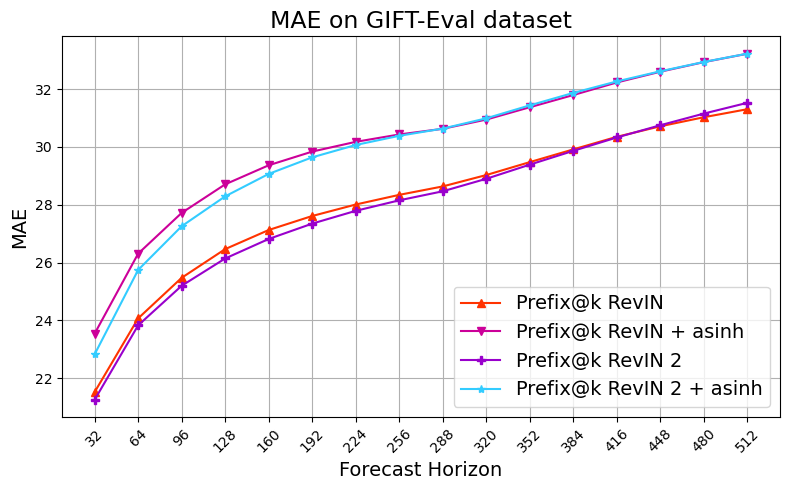

In [137]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mae_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_mae_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_mae_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mae_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

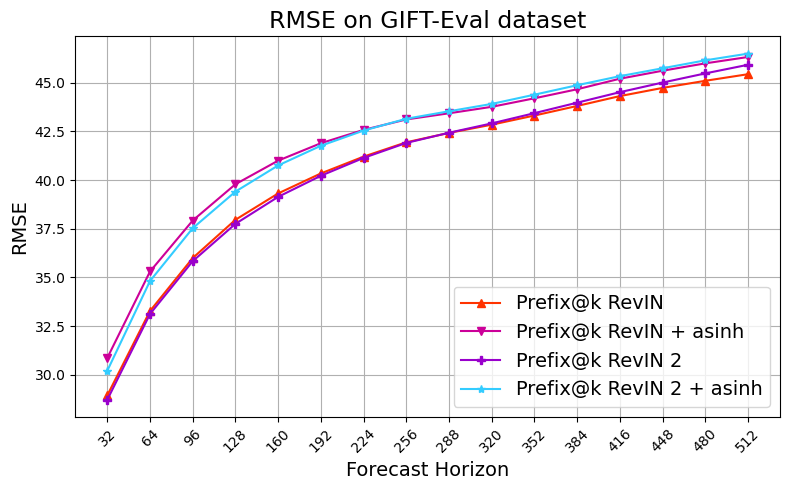

In [138]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_rmse_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_rmse_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_rmse_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/rmse_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

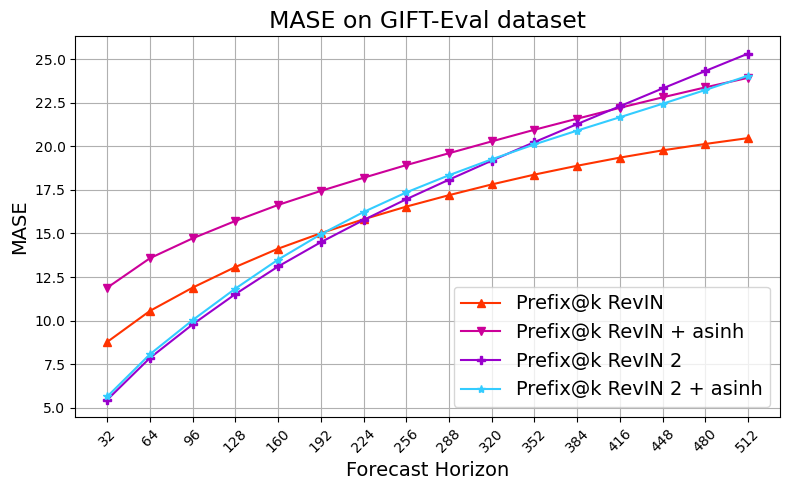

In [139]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mase_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_mase_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_mase_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on GIFT-Eval dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mase_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# UTSD

In [140]:
all_mae_prefix, all_rmse_prefix, all_mase_prefix, sizes = [], [], [], []
for k, v in metrics_prefix_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(v)
        sizes.append(size)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix.append(v)

all_mae_prefix_asinh, all_rmse_prefix_asinh, all_mase_prefix_asinh = [], [], []
for k, v in metrics_prefix_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix_asinh.append(v)
        
all_mae_prefix2, all_rmse_prefix2, all_mase_prefix2 = [], [], []
for k, v in metrics_prefix2_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix2.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix2.append(v)

all_mae_prefix2_asinh, all_rmse_prefix2_asinh, all_mase_prefix2_asinh = [], [], []
for k, v in metrics_prefix2_asinh_utsd.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix2_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix2_asinh.append(v)

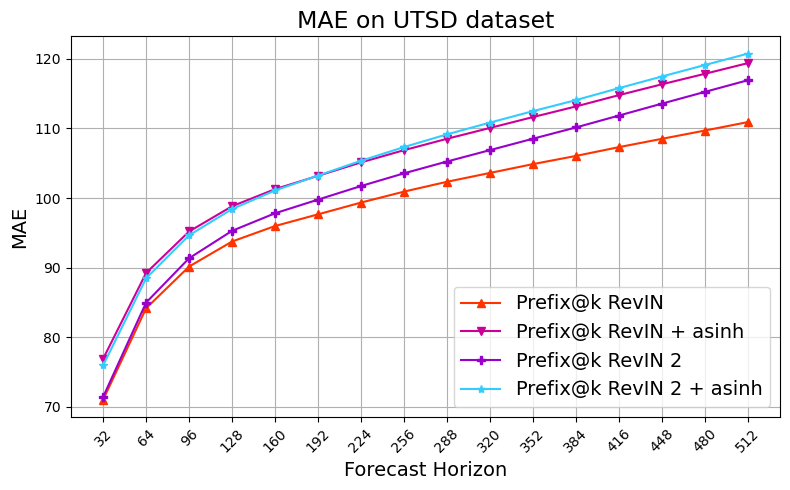

In [141]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mae_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_mae_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_mae_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mae_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

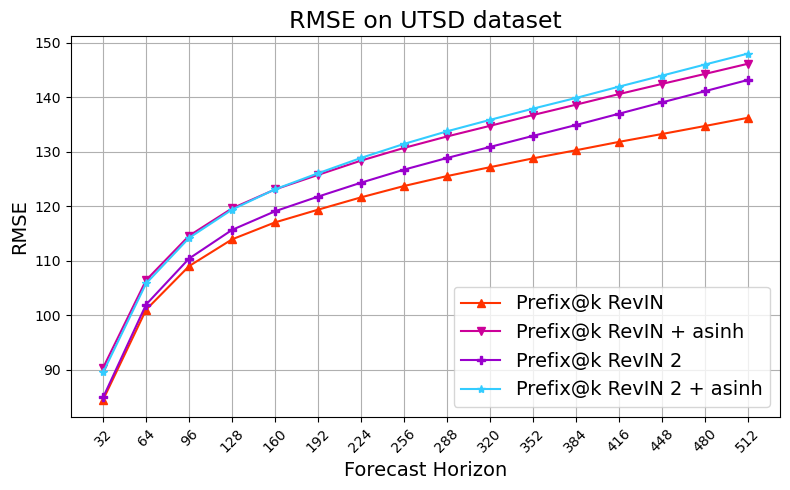

In [142]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_rmse_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_rmse_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_rmse_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/rmse_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

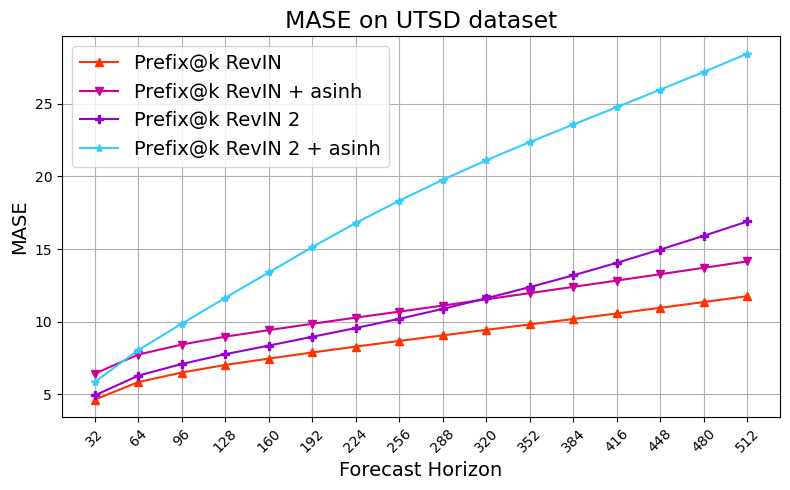

In [143]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mase_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_mase_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_mase_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on UTSD dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mase_ranking_horizon_utsd_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Artificial

In [144]:
all_mae_prefix, all_rmse_prefix, all_mase_prefix, sizes = [], [], [], []
for k, v in metrics_prefix_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix.append(v)
        sizes.append(size)
    elif metric.lower() == "rmse":
        all_rmse_prefix.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix.append(v)

all_mae_prefix_asinh, all_rmse_prefix_asinh, all_mase_prefix_asinh = [], [], []
for k, v in metrics_prefix_asinh_artificial.items(): 
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix_asinh.append(v)

all_mae_prefix2, all_rmse_prefix2, all_mase_prefix2 = [], [], []
for k, v in metrics_prefix2_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix2.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix2.append(v)

all_mae_prefix2_asinh, all_rmse_prefix2_asinh, all_mase_prefix2_asinh = [], [], []
for k, v in metrics_prefix2_asinh_artificial.items():
    metric, size = k.split("_")
    if metric.lower() == "mae":
        all_mae_prefix2_asinh.append(v)
    elif metric.lower() == "rmse":
        all_rmse_prefix2_asinh.append(v)
    elif metric.lower() == "mase":
        all_mase_prefix2_asinh.append(v)

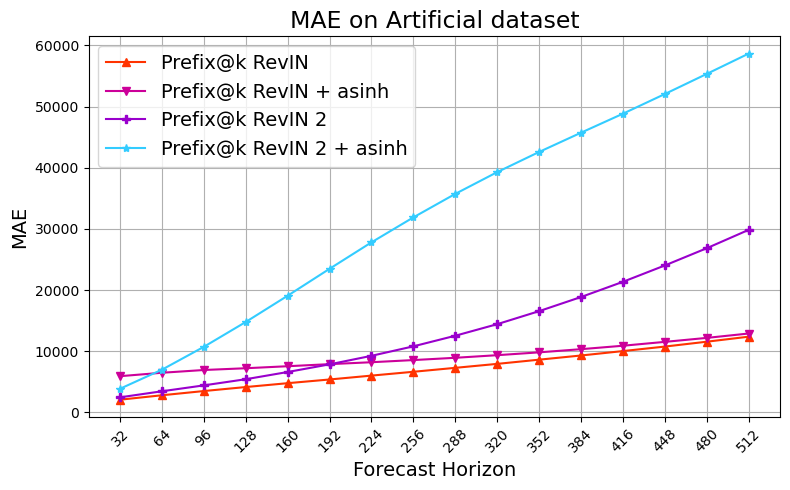

In [145]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mae_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mae_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_mae_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_mae_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MAE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mae_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

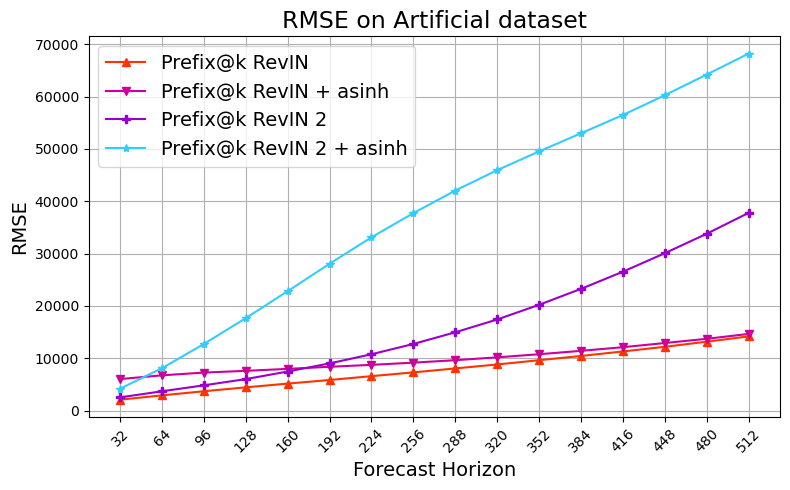

In [146]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_rmse_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_rmse_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_rmse_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_rmse_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("RMSE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/rmse_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

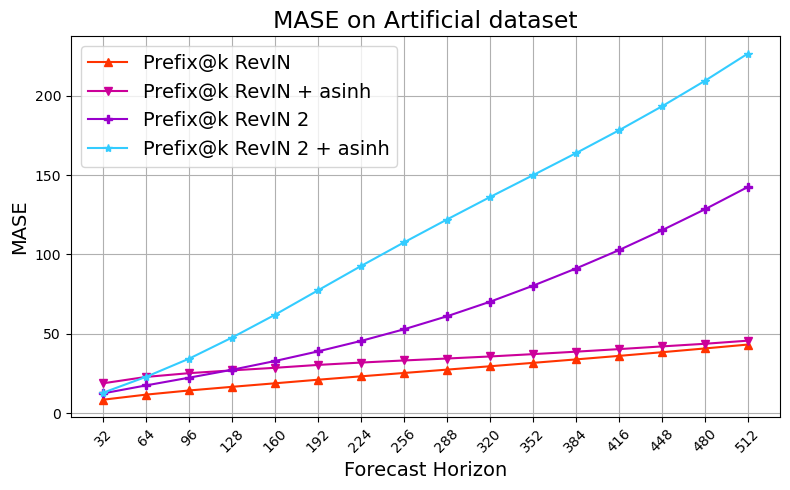

In [147]:
plt.figure(figsize=FIGSIZE)
plt.plot(all_mase_prefix, marker=dic_model_symbols["Prefix RevIN"], label="Prefix@k RevIN", color=dic_model_colors["Prefix RevIN"])
plt.plot(all_mase_prefix_asinh, marker=dic_model_symbols["Prefix RevIN + asinh"], label="Prefix@k RevIN + asinh", color=dic_model_colors["Prefix RevIN + asinh"])
plt.plot(all_mase_prefix2, marker=dic_model_symbols["Prefix RevIN 2"], label="Prefix@k RevIN 2", color=dic_model_colors["Prefix RevIN 2"])
plt.plot(all_mase_prefix2_asinh, marker=dic_model_symbols["Prefix RevIN 2 + asinh"], label="Prefix@k RevIN 2 + asinh", color=dic_model_colors["Prefix RevIN 2 + asinh"])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(sizes)), sizes, rotation=45)
plt.title("MASE on Artificial dataset", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
#plt.savefig(f'figures/plots_prefix/mase_ranking_horizon_artificial_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Critical Rank Diagram

In [148]:
full_df = {}
full_df['Prefix RevIN'] = {
    'GIFT-Eval': metrics_prefix_gift_eval,
    'UTSD': metrics_prefix_utsd,
    'Artificial': metrics_prefix_artificial
}
full_df['Prefix RevIN + asinh'] = {
    'GIFT-Eval': metrics_prefix_asinh_gift_eval,
    'UTSD': metrics_prefix_asinh_utsd,
    'Artificial': metrics_prefix_asinh_artificial
}
full_df['Prefix RevIN 2'] = {
    'GIFT-Eval': metrics_prefix2_gift_eval,
    'UTSD': metrics_prefix2_utsd,
    'Artificial': metrics_prefix2_artificial
}
full_df['Prefix RevIN 2 + asinh'] = {
    'GIFT-Eval': metrics_prefix2_asinh_gift_eval,
    'UTSD': metrics_prefix2_asinh_utsd,
    'Artificial': metrics_prefix2_asinh_artificial
}

In [149]:
new_df_mae = {}
new_df_mse = {}
new_df_mase = {}
for model_name, datasets in full_df.items():
    new_df_mae[model_name] = {}
    new_df_mse[model_name] = {}
    new_df_mase[model_name] = {}
    for dataset_name, metrics in datasets.items():
        for k, v in metrics.items():
            metric, size = k.split("_")
            if metric.lower() == "mae":
                new_df_mae[model_name][f"{dataset_name}_{size}"] = v
            elif metric.lower() == "rmse":
                new_df_mse[model_name][f"{dataset_name}_{size}"] = v 
            elif metric.lower() == "mase":
                new_df_mase[model_name][f"{dataset_name}_{size}"] = v

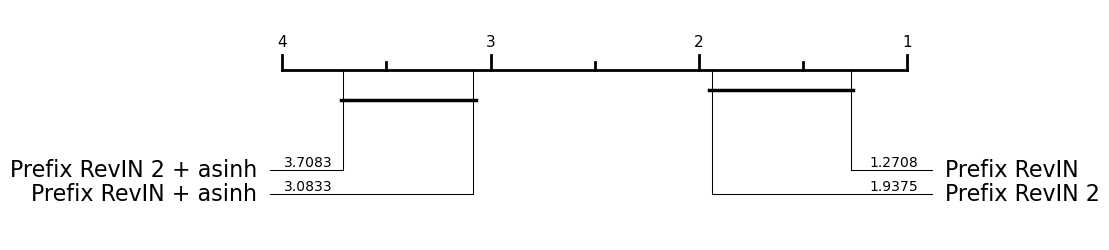

In [150]:
# Create Critical Difference plot for MAE
df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

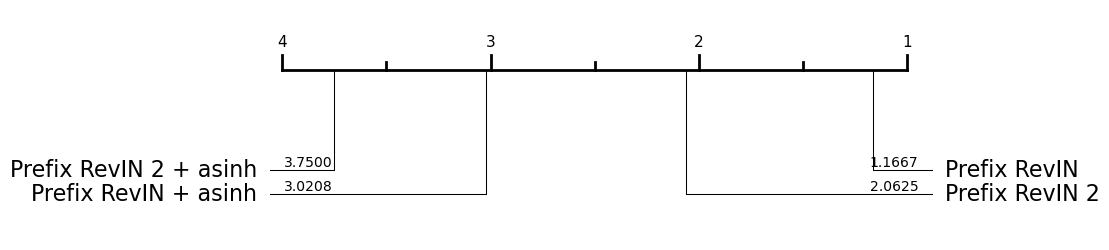

In [151]:
# Create Critical Difference plot for MAE
df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

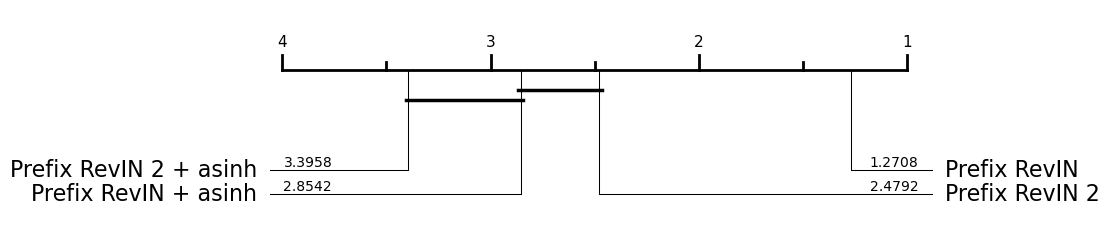

In [152]:
# Create Critical Difference plot for MASE
df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True)

In [153]:
# overall with all context lengths
CTX_LENS = [128, 256, 512, 1024]
full_df = {}
for CTX_LEN in CTX_LENS:

    with open(os.path.join(f"../processed_results/PrefixRevIN_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_prefix_gift_eval = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_prefix_utsd = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_prefix_artificial = json.load(f)

    with open(os.path.join(f"../processed_results/PrefixRevIN_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_prefix_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_prefix_asinh_utsd = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_prefix_asinh_artificial = json.load(f)

    with open(os.path.join(f"../processed_results/PrefixRevIN2_False/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_prefix2_gift_eval = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN2_False/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_prefix2_utsd = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN2_False/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_prefix2_artificial = json.load(f)

    with open(os.path.join(f"../processed_results/PrefixRevIN2_True/{CTX_LEN}", "results_gift_eval.json"), "r") as f:
        metrics_prefix2_asinh_gift_eval = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN2_True/{CTX_LEN}", "results_utsd.json"), "r") as f:
        metrics_prefix2_asinh_utsd = json.load(f)
    with open(os.path.join(f"../processed_results/PrefixRevIN2_True/{CTX_LEN}", "results_artificial.json"), "r") as f:
        metrics_prefix2_asinh_artificial = json.load(f)
    
    full_df[CTX_LEN] = {}
    
    full_df[CTX_LEN]['Prefix RevIN'] = {
        'GIFT-Eval': metrics_prefix_gift_eval,
        'UTSD': metrics_prefix_utsd,
        'Artificial': metrics_prefix_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN + asinh'] = {
        'GIFT-Eval': metrics_prefix_asinh_gift_eval,
        'UTSD': metrics_prefix_asinh_utsd,
        'Artificial': metrics_prefix_asinh_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN 2'] = {
        'GIFT-Eval': metrics_prefix2_gift_eval,
        'UTSD': metrics_prefix2_utsd,
        'Artificial': metrics_prefix2_artificial
    }
    full_df[CTX_LEN]['Prefix RevIN 2 + asinh'] = {
        'GIFT-Eval': metrics_prefix2_asinh_gift_eval,
        'UTSD': metrics_prefix2_asinh_utsd,
        'Artificial': metrics_prefix2_asinh_artificial
    }
new_df_mae = {}
new_df_mse = {}
for CTX_LEN in CTX_LENS:
    for model_name, datasets in full_df[CTX_LEN].items():
        key_prefix = f"{model_name}"
        if key_prefix not in new_df_mae:
            new_df_mae[key_prefix] = {}
            new_df_mse[key_prefix] = {}
        for dataset_name, metrics in datasets.items():
            for k, v in metrics.items():
                metric, size = k.split("_")
                if metric.lower() == "mae":
                    new_df_mae[key_prefix][f"{dataset_name}_{CTX_LEN}_{size}"] = v
                elif metric.lower() == "rmse":
                    new_df_mse[key_prefix][f"{dataset_name}_{CTX_LEN}_{size}"] = v

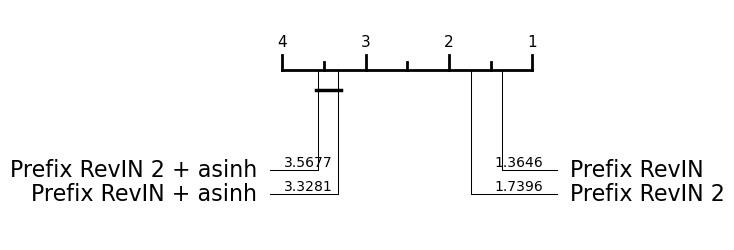

In [154]:
#MAE

df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=4, textspace=1, test='nemenyi', lower_better=True)

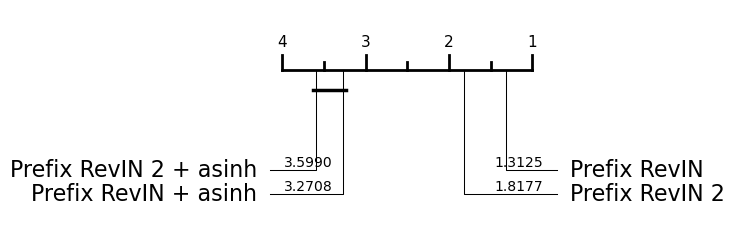

In [155]:
#MSE

df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=5, test='nemenyi', lower_better=True)

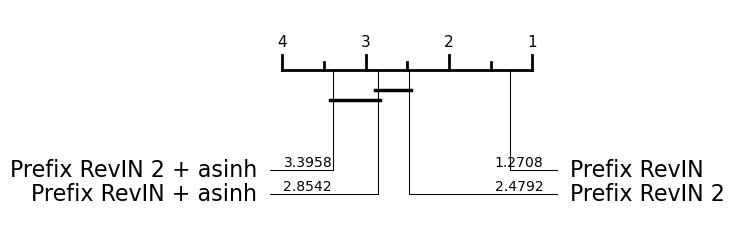

In [156]:
#MASE

df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=4, textspace=1, test='nemenyi', lower_better=True)